In [ ]:
from pathlib import Path
import pickle


try:
    BASE_DIR = Path(__file__).resolve().parent.parent.parent
except NameError:
    BASE_DIR = Path.cwd().parent.parent  # go up 2 levels

DATA_PATH = BASE_DIR / "data" / "RML2016.10a_dict.pkl"

print("Base dir:", BASE_DIR)
print("Data path:", DATA_PATH)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")

with open(DATA_PATH, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print("✅ Loaded successfully")
print("Total keys:", len(data))

Base dir: d:\amr-explainable
Data path: d:\amr-explainable\data\RML2016.10a_dict.pkl
✅ Loaded successfully
Total keys: 220


In [3]:
import numpy as np 
X = []
y = []
snr = []

for (mod, snr_val), signals in data.items():
    X.append(signals)  # append full batch (1000 samples)
    
    # create labels for this batch
    y.extend([mod] * signals.shape[0])
    snr.extend([snr_val] * signals.shape[0])

# Convert efficiently
X = np.vstack(X)   # fast stacking
y = np.array(y)
snr = np.array(snr)

print("✅ Conversion done")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("snr shape:", snr.shape)

print("Modulations:", sorted(set(y)))

print("SNR range:", sorted(set(snr)))

print("One sample shape:", X[0].shape)
print("One label:", y[0])
print("One SNR:", snr[0])

✅ Conversion done
X shape: (220000, 2, 128)
y shape: (220000,)
snr shape: (220000,)
Modulations: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR range: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
One sample shape: (2, 128)
One label: QPSK
One SNR: 2


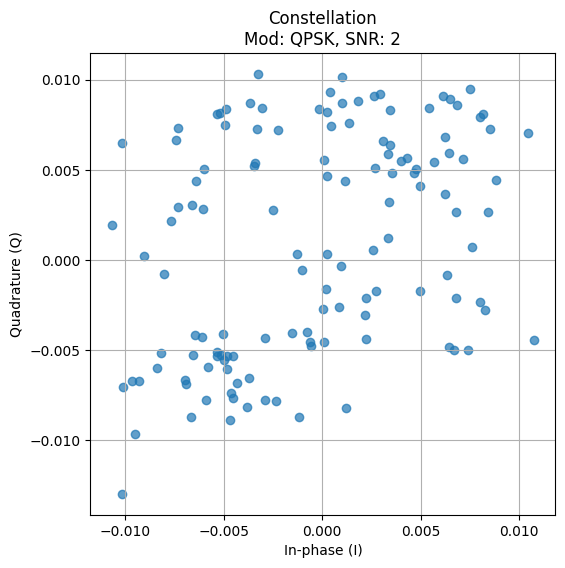

In [4]:
# Visualization 
# Plotting Constellation Graph
import matplotlib.pyplot as plt

# pick any sample
idx = 0
I = X[idx][0]
Q = X[idx][1]

plt.figure(figsize=(6,6))
plt.scatter(I, Q, alpha=0.7)

plt.title(f"Constellation\nMod: {y[idx]}, SNR: {snr[idx]}")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.grid()

plt.show()

#“At low SNR, QPSK constellation points lose their separability due to noise, making classification difficult.”

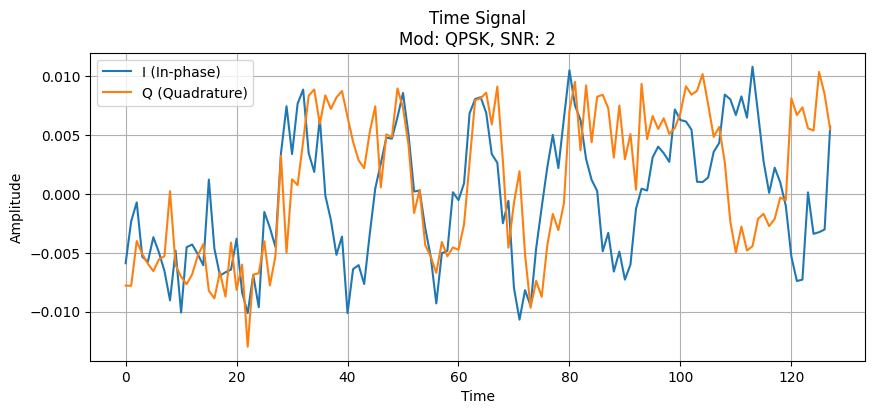

In [5]:
import matplotlib.pyplot as plt

idx = 0

plt.figure(figsize=(10,4))
plt.plot(X[idx][0], label="I (In-phase)")
plt.plot(X[idx][1], label="Q (Quadrature)")

plt.title(f"Time Signal\nMod: {y[idx]}, SNR: {snr[idx]}")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.show()

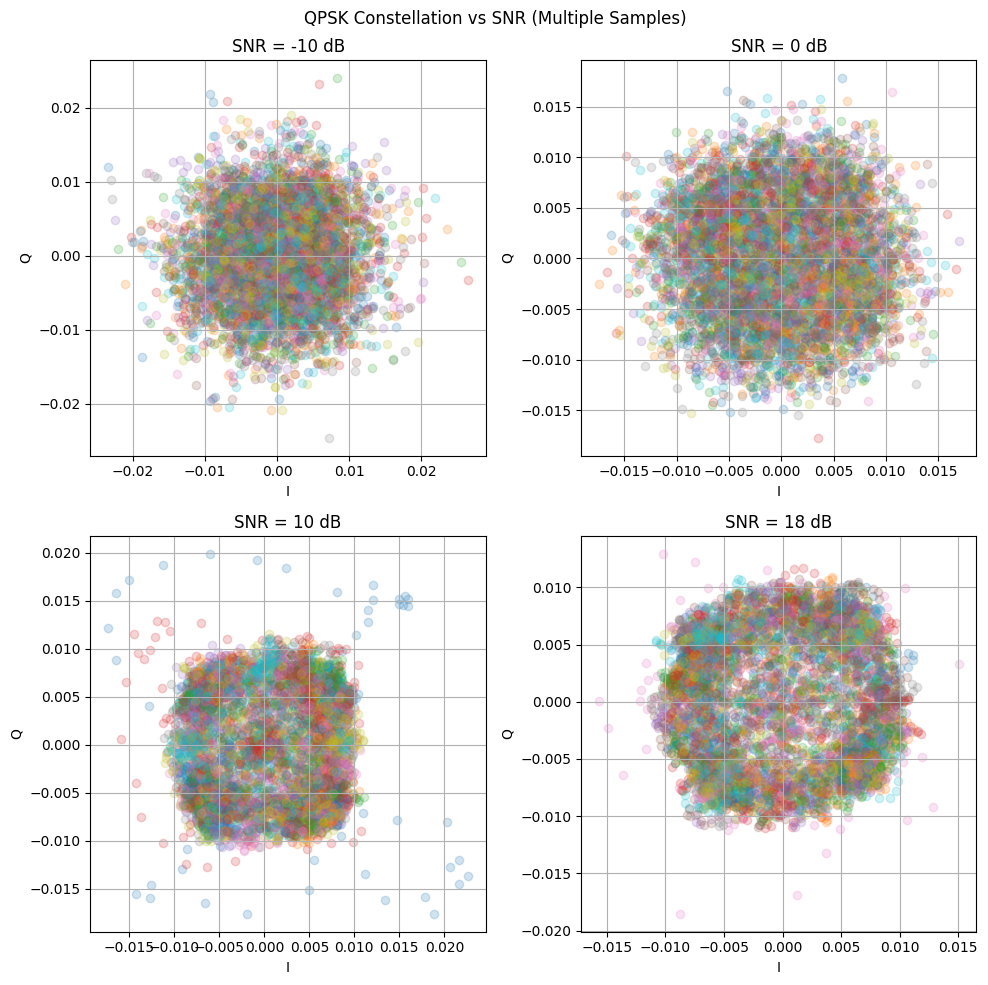

In [6]:
import matplotlib.pyplot as plt

target_mod = "QPSK"
snr_values = [-10, 0, 10, 18]

plt.figure(figsize=(10,10))

for i, snr_val in enumerate(snr_values):
    
    # get multiple samples
    indices = [j for j in range(len(y)) if y[j] == target_mod and snr[j] == snr_val][:50]
    
    plt.subplot(2, 2, i+1)
    
    for idx in indices:
        plt.scatter(X[idx][0], X[idx][1], alpha=0.2)
    
    plt.title(f"SNR = {snr_val} dB")
    plt.xlabel("I")
    plt.ylabel("Q")
    plt.grid()

plt.suptitle(f"{target_mod} Constellation vs SNR (Multiple Samples)")
plt.tight_layout()
plt.show()

In [7]:
import numpy as np

# Avoid division by zero
max_vals = np.max(np.abs(X), axis=(1,2), keepdims=True)
max_vals[max_vals == 0] = 1

X_norm = X / max_vals

print("✅ Normalization done")
print("Range:", X_norm.min(), "to", X_norm.max())

✅ Normalization done
Range: -1.0 to 1.0


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("✅ Encoding done")
print("Classes:", le.classes_)
print("Total classes:", len(le.classes_))

✅ Encoding done
Classes: ['8PSK' 'AM-DSB' 'AM-SSB' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64'
 'QPSK' 'WBFM']
Total classes: 11


In [9]:
from sklearn.model_selection import train_test_split

# Train (70%) + Temp (30%)
X_train, X_temp, y_train, y_temp, snr_train, snr_temp = train_test_split(
    X_norm, y_encoded, snr,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

# Val (15%) + Test (15%)
X_val, X_test, y_val, y_test, snr_val, snr_test = train_test_split(
    X_temp, y_temp, snr_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("✅ Split done")
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

✅ Split done
Train: (154000, 2, 128)
Val: (33000, 2, 128)
Test: (33000, 2, 128)


In [10]:
# transpose last two dimensions

X_train = np.transpose(X_train, (0, 2, 1))
X_val   = np.transpose(X_val,   (0, 2, 1))
X_test  = np.transpose(X_test,  (0, 2, 1))

print("✅ Reshape done")
print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

✅ Reshape done
Train shape: (154000, 128, 2)
Val shape: (33000, 128, 2)
Test shape: (33000, 128, 2)


In [11]:
# we should use 1D CNN cause  its best for signals 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# numpy arrays to tensors 
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)


In [12]:
#Dataloader 
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256)
test_loader = DataLoader(test_dataset, batch_size=256)

In [13]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels=2, out_channels=64, kernel_size=3)
        self.pool = nn.MaxPool1d(2)
        
        self.conv2 = nn.Conv1d(64, 128, 3)
        
        self.fc1 = nn.Linear(128 * 30, 128)  # adjusted size
        self.fc2 = nn.Linear(128, 11)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x):
        x = x.permute(0, 2, 1)  # (batch, channels, time)
        
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        
        x = x.view(x.size(0), -1)
        
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = CNNModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Using device: cuda


In [16]:
# Training our base line model - Only CNN- training on a raw data

epochs = 25
for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # VALIDATION
    model.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            
            val_total += y_batch.size(0)
            val_correct += (predicted == y_batch).sum().item()
    
    val_acc = val_correct / val_total
    
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}, Val Acc: {val_acc:.4f}") # Here whatever printing is total loss means summation of losses of all batches in one epoch 

Epoch 1, Loss: 988.6480, Val Acc: 0.4727
Epoch 2, Loss: 824.7287, Val Acc: 0.4945
Epoch 3, Loss: 795.7925, Val Acc: 0.5024
Epoch 4, Loss: 779.2317, Val Acc: 0.5096
Epoch 5, Loss: 765.7225, Val Acc: 0.5219
Epoch 6, Loss: 752.6567, Val Acc: 0.5193
Epoch 7, Loss: 741.5930, Val Acc: 0.5231
Epoch 8, Loss: 730.6903, Val Acc: 0.5303
Epoch 9, Loss: 717.8315, Val Acc: 0.5325
Epoch 10, Loss: 704.7783, Val Acc: 0.5380
Epoch 11, Loss: 692.6739, Val Acc: 0.5398
Epoch 12, Loss: 679.1662, Val Acc: 0.5417
Epoch 13, Loss: 667.8071, Val Acc: 0.5442
Epoch 14, Loss: 656.8850, Val Acc: 0.5447
Epoch 15, Loss: 647.5811, Val Acc: 0.5377
Epoch 16, Loss: 636.6584, Val Acc: 0.5366
Epoch 17, Loss: 625.6684, Val Acc: 0.5320
Epoch 18, Loss: 615.7913, Val Acc: 0.5281
Epoch 19, Loss: 606.4091, Val Acc: 0.5230
Epoch 20, Loss: 596.6772, Val Acc: 0.5348
Epoch 21, Loss: 587.1078, Val Acc: 0.5298
Epoch 22, Loss: 580.2235, Val Acc: 0.5260
Epoch 23, Loss: 571.4742, Val Acc: 0.5273
Epoch 24, Loss: 562.3202, Val Acc: 0.5277
E

In [17]:
from collections import defaultdict

model.eval()

snr_correct = defaultdict(int)
snr_total = defaultdict(int)

with torch.no_grad():
    for X_batch, y_batch, snr_batch in zip(X_test_t, y_test_t, snr_test):
        
        X_batch = X_batch.unsqueeze(0).to(device)
        y_batch = y_batch.unsqueeze(0).to(device)
        
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        
        snr_val = int(snr_batch)
        
        snr_total[snr_val] += 1
        if predicted.item() == y_batch.item():
            snr_correct[snr_val] += 1

# compute accuracy
snr_acc = {snr: snr_correct[snr]/snr_total[snr] for snr in snr_total}

# sort
snr_acc = dict(sorted(snr_acc.items()))

print(snr_acc)

{-20: 0.10161386730424388, -18: 0.10611510791366907, -16: 0.10652304009575105, -14: 0.13963681903569192, -12: 0.15757204169221337, -10: 0.22642762284196546, -8: 0.27932960893854747, -6: 0.37005477784540475, -4: 0.47706968433591423, -2: 0.6171967020023557, 0: 0.7035452322738386, 2: 0.7516262566528681, 4: 0.7836222355050807, 6: 0.8217761557177615, 8: 0.788391777509069, 10: 0.7885783718104495, 12: 0.8113879003558719, 14: 0.7915129151291513, 16: 0.7828134196586227, 18: 0.815947242206235}


# 📊 Conclusion: CNN Baseline Performance on RadioML Dataset

The CNN model was trained on normalized raw I/Q signal samples for **25 epochs** without incorporating advanced signal processing features or temporal modeling. The model achieved a peak validation accuracy of approximately **54.4%**, establishing a solid baseline for Automatic Modulation Recognition (AMR).

A detailed SNR-wise analysis highlights the strong dependency of model performance on channel conditions:

- At **very low SNR (-20 to -16 dB)**, accuracy remains close to random (~10%), indicating that noise dominates the signal and obscures modulation patterns.
- In the **low-to-mid SNR range (-14 to -2 dB)**, performance improves steadily (~14% → ~61%) as underlying signal structures begin to emerge from noise.
- In the **moderate SNR region (0 to 6 dB)**, the model achieves strong performance (~70% → ~82%), showing effective learning of constellation characteristics.
- At **high SNR (8 to 18 dB)**, accuracy stabilizes around **78%–82%**, indicating saturation in performance.

Although the CNN successfully captures local patterns in the I/Q data, the validation accuracy peaks around **epoch 14 (~54.4%)** and then begins to decline, suggesting **overfitting** and limited representational capacity.

These results indicate that while CNN provides a reliable baseline, it is insufficient for capturing:

- Long-range temporal dependencies  
- Complex relationships between signal samples  

This motivates the need for more advanced architectures such as:

- **CNN-LSTM** for temporal modeling  
- **Graph Neural Networks (GNNs)** for relational and structural learning  

Overall, the observed trend aligns with communication theory:

> **Classification accuracy improves with increasing SNR**, validating both the dataset and the implemented learning pipeline.

In [23]:
# CNN - LSTM architecture 

class CNN_LSTM(nn.Module):
    def __init__(self):
        super(CNN_LSTM, self).__init__()
        
        # CNN part
        self.conv1 = nn.Conv1d(2, 64, kernel_size=3)
        self.pool = nn.MaxPool1d(2)
        
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3)
        
        # LSTM part
        self.lstm = nn.LSTM(input_size=128, hidden_size=64, batch_first=True)
        
        # Fully connected
        self.fc1 = nn.Linear(64, 128)
        self.fc2 = nn.Linear(128, 11)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x):
        # (batch, 128, 2) → (batch, 2, 128)
        x = x.permute(0, 2, 1)
        
        # CNN
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        
        # back to (batch, seq, features)
        x = x.permute(0, 2, 1)
        
        # LSTM
        x, _ = self.lstm(x)
        
        # take last time step
        x = x[:, -1, :]
        
        # Dense
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

In [24]:
model_lstm = CNN_LSTM().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

In [25]:
# Training our base line model 2 - Only CNN + LSTM - training on raw data

epochs = 25

for epoch in range(epochs):
    
    model_lstm.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        
        outputs = model_lstm(X_batch)   
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # VALIDATION
    model_lstm.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            outputs = model_lstm(X_batch)   
            
            _, predicted = torch.max(outputs, 1)
            
            val_total += y_batch.size(0)
            val_correct += (predicted == y_batch).sum().item()
    
    val_acc = val_correct / val_total
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1, Loss: 1.7069, Val Acc: 0.4662
Epoch 2, Loss: 1.3176, Val Acc: 0.4967
Epoch 3, Loss: 1.2594, Val Acc: 0.5164
Epoch 4, Loss: 1.2305, Val Acc: 0.5302
Epoch 5, Loss: 1.2107, Val Acc: 0.5393
Epoch 6, Loss: 1.1968, Val Acc: 0.5439
Epoch 7, Loss: 1.1850, Val Acc: 0.5475
Epoch 8, Loss: 1.1690, Val Acc: 0.5584
Epoch 9, Loss: 1.1522, Val Acc: 0.5631
Epoch 10, Loss: 1.1392, Val Acc: 0.5658
Epoch 11, Loss: 1.1306, Val Acc: 0.5676
Epoch 12, Loss: 1.1230, Val Acc: 0.5689
Epoch 13, Loss: 1.1187, Val Acc: 0.5719
Epoch 14, Loss: 1.1147, Val Acc: 0.5705
Epoch 15, Loss: 1.1078, Val Acc: 0.5716
Epoch 16, Loss: 1.1041, Val Acc: 0.5748
Epoch 17, Loss: 1.1016, Val Acc: 0.5726
Epoch 18, Loss: 1.0960, Val Acc: 0.5779
Epoch 19, Loss: 1.0926, Val Acc: 0.5733
Epoch 20, Loss: 1.0894, Val Acc: 0.5722
Epoch 21, Loss: 1.0857, Val Acc: 0.5735
Epoch 22, Loss: 1.0825, Val Acc: 0.5768
Epoch 23, Loss: 1.0789, Val Acc: 0.5749
Epoch 24, Loss: 1.0753, Val Acc: 0.5756
Epoch 25, Loss: 1.0718, Val Acc: 0.5750


In [26]:
from collections import defaultdict
import torch

model_lstm.eval()

snr_correct = defaultdict(int)
snr_total = defaultdict(int)

with torch.no_grad():
    for i in range(len(X_test)):
        
        x = torch.tensor(X_test[i], dtype=torch.float32).unsqueeze(0).to(device)
        y_true = y_test[i]
        snr_val = int(snr_test[i])
        
        outputs = model_lstm(x)
        _, pred = torch.max(outputs, 1)
        
        if pred.item() == y_true:
            snr_correct[snr_val] += 1
        
        snr_total[snr_val] += 1

# compute accuracy
snr_acc_lstm = {snr: snr_correct[snr] / snr_total[snr] for snr in snr_total}
snr_acc_lstm = dict(sorted(snr_acc_lstm.items()))

print(snr_acc_lstm)

{-20: 0.1022115959354453, -18: 0.09952038369304557, -16: 0.09874326750448834, -14: 0.15529117094552286, -12: 0.1863887185775598, -10: 0.25697211155378485, -8: 0.382991930477964, -6: 0.527084601339014, -4: 0.6396664681357951, -2: 0.7126030624263839, 0: 0.8080684596577017, 2: 0.8314606741573034, 4: 0.8398087268380156, 6: 0.8503649635036497, 8: 0.845223700120919, 10: 0.8444714459295262, 12: 0.8558718861209964, 14: 0.8185731857318573, 16: 0.8446144791053561, 18: 0.854916067146283}


# 📊 Conclusion: CNN-LSTM Performance on RadioML Dataset

The CNN-LSTM model was trained on normalized raw I/Q signal samples to capture both local signal patterns (via CNN) and temporal dependencies (via LSTM). The model achieved a peak validation accuracy of approximately **57.8%**, showing a clear improvement over the CNN baseline.

A detailed SNR-wise analysis highlights the impact of channel conditions on performance:

- At **very low SNR (-20 to -16 dB)**, accuracy remains close to random (~10%), indicating that noise heavily distorts the signal and limits meaningful feature extraction.
- In the **low-to-mid SNR range (-14 to -2 dB)**, performance improves significantly (~15% → ~71%), demonstrating that the CNN-LSTM model better captures temporal relationships compared to CNN alone.
- In the **moderate SNR region (0 to 6 dB)**, accuracy increases further (~80% → ~85%), showing strong recognition capability as signal structure becomes clearer.
- At **high SNR (8 to 18 dB)**, performance stabilizes around **84%–85%**, indicating saturation despite improved modeling capacity.

Compared to the CNN baseline, the CNN-LSTM model shows:

- Improved performance across most SNR ranges  
- Better robustness in noisy conditions  
- More stable learning due to temporal feature extraction  

However, despite these gains, performance still saturates at high SNR, suggesting that:

- Temporal modeling alone is not sufficient  
- The model does not fully capture the **geometric and relational structure** of modulation signals  

This highlights the need for more advanced architectures such as:

- **Graph Neural Networks (GNNs)** for relational learning  
- Hybrid models combining signal processing features with deep learning  

Overall, the results confirm that incorporating temporal dependencies improves modulation recognition, especially under noisy conditions, while maintaining consistency with communication theory:

> **Classification accuracy improves with increasing SNR**, validating both the dataset and the modeling approach.

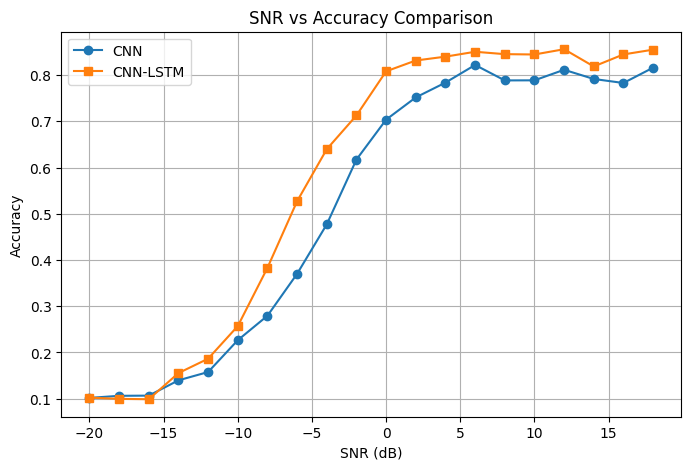

In [27]:
import matplotlib.pyplot as plt

# CNN
snr_vals = list(snr_acc.keys())
cnn_acc = list(snr_acc.values())

# CNN-LSTM
lstm_acc = [snr_acc_lstm[snr] for snr in snr_vals]

plt.figure(figsize=(8,5))

plt.plot(snr_vals, cnn_acc, marker='o', label="CNN")
plt.plot(snr_vals, lstm_acc, marker='s', label="CNN-LSTM")

plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("SNR vs Accuracy Comparison")
plt.legend()
plt.grid()

plt.show()

# 📊 Conclusion: CNN vs CNN-LSTM Performance Comparison

The comparative analysis between CNN and CNN-LSTM models highlights the importance of temporal modeling in Automatic Modulation Recognition (AMR).

At **very low SNR levels (-20 to -16 dB)**, both models exhibit near-random performance (~10%), as noise dominates the signal and obscures meaningful patterns. In this regime, neither spatial nor temporal features are sufficiently informative.

In the **low-to-mid SNR range (-14 to -2 dB)**, the CNN-LSTM model consistently outperforms CNN. The improvement is especially noticeable from **-8 dB onward**, where CNN-LSTM leverages temporal dependencies to better capture signal structure under noise. This results in a significant accuracy gain compared to CNN.

In the **moderate SNR region (0 to 6 dB)**, CNN-LSTM achieves strong performance (~80%–85%), clearly surpassing CNN (~70%–82%). This demonstrates that temporal modeling enhances feature representation when signal patterns become more distinguishable.

At **high SNR levels (8 to 18 dB)**, both models reach performance saturation. While CNN-LSTM still maintains a slight advantage (~2–4%), the gap reduces, indicating that when the signal is clean, local feature extraction alone is often sufficient.

Overall, the results show that:

- CNN effectively captures **local spatial patterns** in I/Q signals  
- CNN-LSTM improves performance by modeling **temporal dependencies**  
- The largest gains from LSTM occur in **noisy and mid-SNR conditions**  

Despite these improvements, both models exhibit performance saturation at high SNR and limited robustness at very low SNR. This suggests that:

- Current architectures do not fully capture the **intrinsic geometric and relational structure** of modulation signals  

This motivates the use of **Graph Neural Networks (GNNs)**, which can model relationships between signal samples more effectively and potentially improve performance across all SNR regimes.

> Overall, the observed trend aligns with communication theory:  
> **Modulation classification accuracy increases with SNR**, validating both the dataset and the learning framework.